In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

In [20]:
df=pd.read_csv('Iris.csv')
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [21]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [23]:
df.shape

(150, 6)

In [24]:
x=df.iloc[:,1:5]
x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [30]:
y = df.select_dtypes(include=['object'])
y

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


In [26]:
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

In [27]:
cov_mat = np.cov(x.T)
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)
print("Eigenvalues:\n {} \n".format(eigen_values))
print("Eigenvectors:\n {} \n".format(eigen_vectors))
print("Covariance Matrix:\n {} \n".format(cov_mat))

Eigenvalues:
 [4.22484077 0.24224357 0.07852391 0.02368303] 

Eigenvectors:
 [[ 0.36158968 -0.65653988 -0.58099728  0.31725455]
 [-0.08226889 -0.72971237  0.59641809 -0.32409435]
 [ 0.85657211  0.1757674   0.07252408 -0.47971899]
 [ 0.35884393  0.07470647  0.54906091  0.75112056]] 

Covariance Matrix:
 [[ 0.68569351 -0.03926846  1.27368233  0.5169038 ]
 [-0.03926846  0.18800403 -0.32171275 -0.11798121]
 [ 1.27368233 -0.32171275  3.11317942  1.29638747]
 [ 0.5169038  -0.11798121  1.29638747  0.58241432]] 



In [28]:
eigen_pairs = [(np.abs(eigen_values[i]), eigen_vectors[:,i]) for i in range(len(eigen_values))]
print("Eigen Values in descending order:")
eigen_pairs.sort(key=lambda x: x[0], reverse=True)
for eigen_value, eigen_vector in eigen_pairs:
    print(eigen_value)

Eigen Values in descending order:
4.224840768320111
0.242243571627515
0.07852390809415462
0.023683027126002284


In [36]:
pca=PCA()
pca=pca.fit(x_scaled)

In [37]:
explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.72770452, 0.23030523, 0.03683832, 0.00515193])

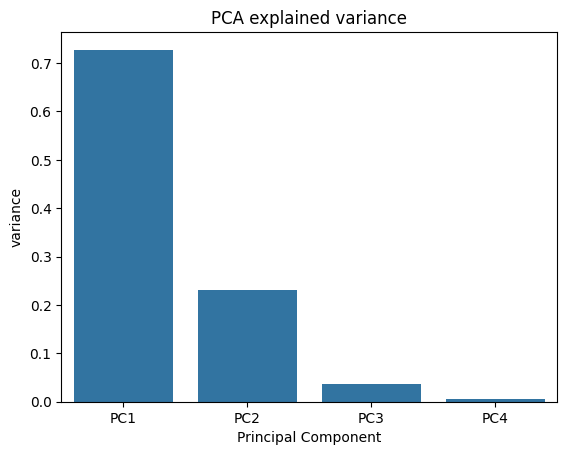

In [38]:
data=pd.DataFrame({'variance':pca.explained_variance_ratio_,'Principal Component':['PC1','PC2','PC3','PC4']})
sns.barplot(x='Principal Component',y='variance', data=data)
plt.title("PCA explained variance")
plt.show()


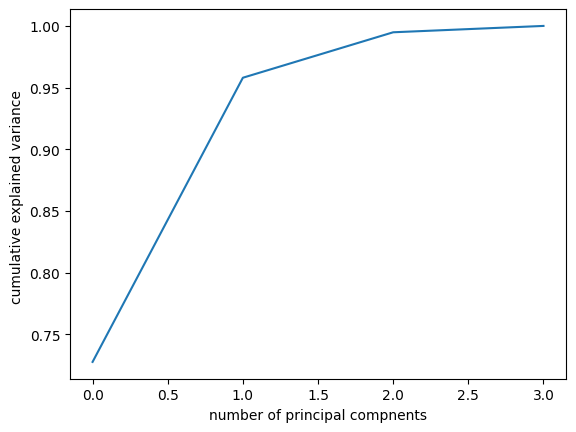

In [39]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("number of principal compnents")
plt.ylabel("cumulative explained variance ")
plt.show()

In [41]:
pca_2=PCA(n_components=2)
pca_2=pca_2.fit(x_scaled)
pca_2d=pca_2.transform(x)
pca_2d

c:\Users\kolhe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


array([[2.66923088, 5.18088722],
       [2.69643401, 4.6436453 ],
       [2.4811633 , 4.75218345],
       [2.57151243, 4.62661492],
       [2.59065822, 5.23621104],
       [3.00809881, 5.68221692],
       [2.49094166, 4.90871397],
       [2.70145461, 5.05320922],
       [2.46158369, 4.36493047],
       [2.67166282, 4.73176885],
       [2.83139678, 5.47980351],
       [2.65510568, 4.98085502],
       [2.58763574, 4.59987189],
       [2.15207373, 4.40738428],
       [2.78696275, 5.90006937],
       [2.91688204, 6.25247172],
       [2.77559721, 5.67377901],
       [2.72579198, 5.1874288 ],
       [3.13458468, 5.6948152 ],
       [2.70491091, 5.46720523],
       [3.02665406, 5.20635552],
       [2.78780751, 5.38119115],
       [2.14920797, 5.07884578],
       [3.06596138, 5.02172909],
       [2.82948189, 4.98718345],
       [2.86492198, 4.6850961 ],
       [2.87270222, 5.06840185],
       [2.77959344, 5.22022854],
       [2.74780353, 5.12556341],
       [2.65553951, 4.75851189],
       [2.

In [ ]:
df['Species']=df['Species'].replace({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})

C:\Users\kolhe\AppData\Local\Temp\ipykernel_5636\3770966463.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Species']=df['Species'].replace({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})


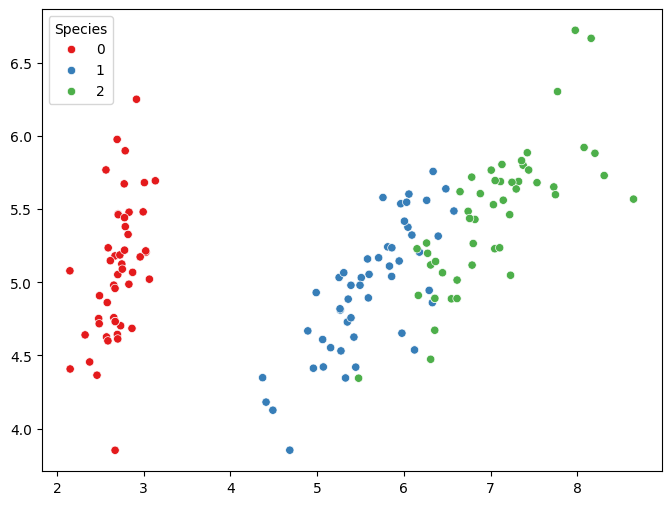

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1],hue=df['Species'], palette='Set1')
plt.show()

In [44]:
pca_4=PCA(n_components=4)
pca_4=pca_4.fit(x_scaled)
pca_4d=pca_4.transform(x)

c:\Users\kolhe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


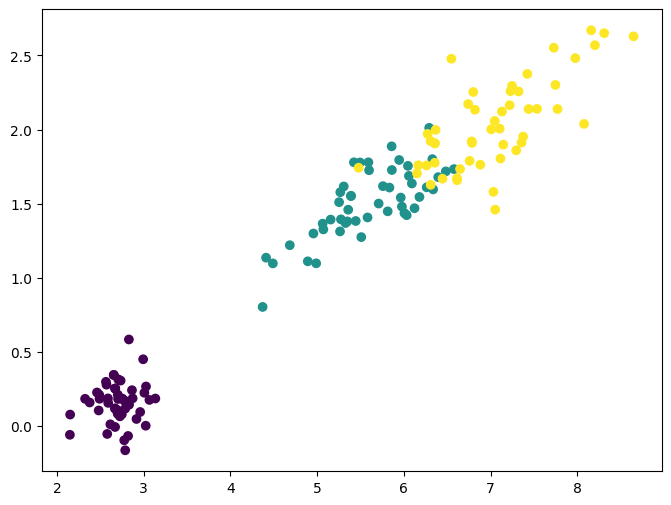

In [45]:
plt.figure(figsize=(8,6))
plt.scatter(pca_4d[:,0],pca_4d[:,3],c=df['Species'])
plt.show()